# 03 — Vectorisation, Pretrained Models and Comparative Analysis

This notebook converts the cleaned multimodal datasets into numerical feature spaces and compares different vectorisation methods.

Project: **Reconstructing Wonderland: A Data-Driven Spatial Narrative**

The notebook works with the cleaned datasets produced by:

`02_data_processing.ipynb`

It prepares the analytical foundation for later parameter mapping, Blender fragment generation, TouchDesigner point-cloud behaviour, and AI-assisted scene generation.

## 1. Analytical Strategy

This notebook treats the three datasets as complementary forms of information:

- **Text** provides narrative and semantic structure.
- **Images** provide visual reference, colour, texture and atmosphere.
- **Audio** provides rhythm, intensity and temporal behaviour.

The main aims are:

1. Vectorise each dataset.
2. Compare multiple vectorisation methods.
3. Use pretrained machine learning models where appropriate.
4. Visualise the resulting feature spaces with Matplotlib and Seaborn.
5. Save processed feature tables for downstream design mapping.

In [48]:
from pathlib import Path
import os
import re
import json
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

sns.set_context("notebook")
sns.set_style("whitegrid")

In [49]:
# =========================
# Project paths
# =========================

PROJECT_ROOT = Path("../..")

DATA_DIR = PROJECT_ROOT / "data"

CLEANED_DIR = DATA_DIR / "cleaned"
PROCESSED_DIR = DATA_DIR / "processed"

TEXT_CLEANED_PATH = CLEANED_DIR / "text" / "text_cleaned.csv"
IMAGE_CLEANED_PATH = CLEANED_DIR / "images" / "image_cleaned.csv"
AUDIO_CLEANED_PATH = CLEANED_DIR / "audio" / "audio_cleaned.csv"

TEXT_VECTOR_DIR = PROCESSED_DIR / "text_vectors"
IMAGE_VECTOR_DIR = PROCESSED_DIR / "image_vectors"
AUDIO_VECTOR_DIR = PROCESSED_DIR / "audio_vectors"

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "part1_vectorisation"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

for folder in [
    PROCESSED_DIR,
    TEXT_VECTOR_DIR,
    IMAGE_VECTOR_DIR,
    AUDIO_VECTOR_DIR,
    FIGURE_DIR,
    TABLE_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Cleaned text:", TEXT_CLEANED_PATH)
print("Cleaned image:", IMAGE_CLEANED_PATH)
print("Cleaned audio:", AUDIO_CLEANED_PATH)
print("Figure output:", FIGURE_DIR)

Project root: D:\Work\Workspace\Projects\Python\reconstructing-wonderland
Cleaned text: ..\..\data\cleaned\text\text_cleaned.csv
Cleaned image: ..\..\data\cleaned\images\image_cleaned.csv
Cleaned audio: ..\..\data\cleaned\audio\audio_cleaned.csv
Figure output: ..\..\outputs\figures\part1_vectorisation


In [50]:
# =========================
# Helper functions
# =========================

def save_dataframe(df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print("Saved:", path)


def save_array(array, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    np.save(path, array)
    print("Saved:", path)


def safe_text(x):
    if pd.isna(x):
        return ""
    return str(x).replace("\n", " ").replace("\r", " ").strip()


def resolve_path(path_value, fallback_folder=None, file_name=None):
    """
    Robustly resolve stored paths from metadata.
    """
    candidates = []

    if path_value is not None and not pd.isna(path_value):
        p = Path(str(path_value))
        candidates.append(p)
        candidates.append(PROJECT_ROOT / p)

    if fallback_folder is not None and file_name is not None:
        candidates.append(fallback_folder / str(file_name))

    for p in candidates:
        if p.exists():
            return p

    return None


def pca_dataframe(matrix, labels=None, n_components=2):
    pca = PCA(n_components=n_components, random_state=42)
    coords = pca.fit_transform(matrix)

    df = pd.DataFrame(coords, columns=[f"PC{i+1}" for i in range(n_components)])

    if labels is not None:
        df["label"] = labels

    return df, pca


def run_kmeans(matrix, n_clusters=6, random_state=42):
    """
    Run KMeans and return labels and silhouette score.
    """
    if len(matrix) <= n_clusters:
        labels = np.zeros(len(matrix), dtype=int)
        return labels, np.nan

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(matrix)

    try:
        score = silhouette_score(matrix, labels)
    except Exception:
        score = np.nan

    return labels, score

## 2. Load Cleaned Datasets

The notebook reads the cleaned datasets from the previous processing stage:

```text
data/cleaned/text/text_cleaned.csv
data/cleaned/images/image_cleaned.csv
data/cleaned/audio/audio_cleaned.csv
```

These cleaned datasets become the basis for vectorisation and model comparison.

In [51]:
text_df = pd.read_csv(TEXT_CLEANED_PATH)
image_df = pd.read_csv(IMAGE_CLEANED_PATH)
audio_df = pd.read_csv(AUDIO_CLEANED_PATH)

print("Text dataset:", text_df.shape)
print("Image dataset:", image_df.shape)
print("Audio dataset:", audio_df.shape)

display(text_df.head(3))
display(image_df.head(3))
display(audio_df.head(3))

Text dataset: (288, 13)
Image dataset: (278, 20)
Audio dataset: (270, 24)


,text_id,source,chapter_index,chapter_title,text,char_count,word_count,type,text_clean,is_too_short,is_too_long,is_empty,length_group
0,text_0000,Alice's Adventures in Wonderland,0,Full Text,Alice was beginning to get very tired of sitti...,591,112,narrative,Alice was beginning to get very tired of sitti...,False,False,False,medium
1,text_0001,Alice's Adventures in Wonderland,0,Full Text,There was nothing so VERY remarkable in that; ...,149,31,narrative,There was nothing so VERY remarkable in that; ...,False,False,False,very_short
2,text_0002,Alice's Adventures in Wonderland,0,Full Text,I shall be late!' (when she thought it over af...,584,111,narrative,I shall be late!' (when she thought it over af...,False,False,False,medium


,image_id,file_name,file_path,category,query,source_api,source_url,image_download_url,photographer,width,height,license,tags,date_taken,quality_status,resolved_path,exists,is_valid_image,aspect_ratio,mode
0,img_0002,img_0002.jpg,..\..\data\raw\images\img_0002.jpg,alice,Alice in Wonderland blue dress illustration,Pexels,https://www.pexels.com/photo/woman-wearing-gre...,https://images.pexels.com/photos/771323/pexels...,Min An,650,650,Pexels License,NaN,NaN,unreviewed,..\..\data\raw\images\img_0002.jpg,True,True,1.000000,RGB
1,img_0007,img_0007.jpg,..\..\data\raw\images\img_0007.jpg,alice,Alice in Wonderland blue dress illustration,Pexels,https://www.pexels.com/photo/close-up-shot-of-...,https://images.pexels.com/photos/6145306/pexel...,June,650,650,Pexels License,NaN,NaN,unreviewed,..\..\data\raw\images\img_0007.jpg,True,True,1.000000,RGB
2,img_0015,img_0015.jpg,..\..\data\raw\images\img_0015.jpg,alice,Alice in Wonderland blue dress illustration,Flickr,https://www.flickr.com/photos/24678924@N08/815...,https://live.staticflickr.com/7108/8159270801_...,NaN,592,800,0,pink blue woman white black cute rabbit bunny ...,NaN,unreviewed,..\..\data\raw\images\img_0015.jpg,True,True,1.351351,RGB


,id,source,freesound_id,name,username,license,duration,tags,description,audio_url,...,category,query,source_api,source_url,audio_download_url,created,resolved_path,exists,duration_numeric,duration_status
0,NaN,NaN,NaN,male voices forest NL171104_1233.wav,klankbeeld,https://creativecommons.org/licenses/by/4.0/,29.6530,"Dutch,Netherlands,ambience,ambient,field-recor...",NaN,NaN,...,ambient,forest ambience,Freesound,https://freesound.org/people/klankbeeld/sounds...,https://cdn.freesound.org/previews/608/608314_...,2021-11-12T06:35:51Z,..\..\data\raw\audio\audio_0350.mp3,True,29.6530,known
1,NaN,NaN,NaN,edge forest 735AM 210221_0257.wav,klankbeeld,https://creativecommons.org/licenses/by/4.0/,15.3626,"Holland,Loonse-en-Drunense-Duinen,Netherlands,...",NaN,NaN,...,ambient,forest ambience,Freesound,https://freesound.org/people/klankbeeld/sounds...,https://cdn.freesound.org/previews/619/619325_...,2022-02-12T17:50:17Z,..\..\data\raw\audio\audio_0351.mp3,True,15.3626,known
2,NaN,NaN,NaN,amb_forest_crickets.wav,Dokuta_Gerovv,http://creativecommons.org/publicdomain/zero/1.0/,14.4853,"ambience,ambient,atmosphere,crickets,fie,field...",NaN,NaN,...,ambient,forest ambience,Freesound,https://freesound.org/people/Dokuta_Gerovv/sou...,https://cdn.freesound.org/previews/662/662090_...,2022-12-01T08:50:08Z,..\..\data\raw\audio\audio_0352.mp3,True,14.4853,known


Saved: ..\..\outputs\tables\03_vectorisation_dataset_summary.csv


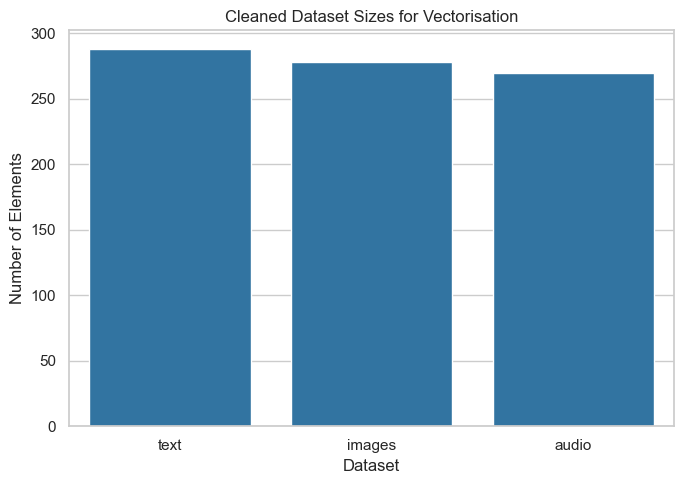

,dataset,count
0,text,288
1,images,278
2,audio,270


In [52]:
dataset_summary = pd.DataFrame({
    "dataset": ["text", "images", "audio"],
    "count": [len(text_df), len(image_df), len(audio_df)]
})

save_dataframe(dataset_summary, TABLE_DIR / "03_vectorisation_dataset_summary.csv")

plt.figure(figsize=(7, 5))
sns.barplot(data=dataset_summary, x="dataset", y="count")
plt.title("Cleaned Dataset Sizes for Vectorisation")
plt.xlabel("Dataset")
plt.ylabel("Number of Elements")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "00_cleaned_dataset_sizes.png", dpi=220)
plt.show()

dataset_summary

In [53]:
text_df = pd.read_csv(TEXT_CLEANED_PATH)
image_df = pd.read_csv(IMAGE_CLEANED_PATH)
audio_df = pd.read_csv(AUDIO_CLEANED_PATH)

In [56]:
# =========================
# Force rebuild text dataset from alice_original.txt
# =========================
# This fixes cases where text_raw.csv / text_cleaned.csv still contain "Full Text"
# instead of chapter-level structure.

from pathlib import Path
import re
import pandas as pd

ALICE_ORIGINAL_PATH = DATA_DIR / "raw" / "text" / "alice_original.txt"

if not ALICE_ORIGINAL_PATH.exists():
    raise FileNotFoundError(f"Cannot find Alice original text: {ALICE_ORIGINAL_PATH}")

raw_alice_text = ALICE_ORIGINAL_PATH.read_text(encoding="utf-8", errors="ignore")


def clean_text_string(text):
    text = str(text)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    return text


def extract_alice_body_from_original(raw_text):
    """
    Extract the main body of Alice's Adventures in Wonderland.
    Supports chapter headings such as:
    CHAPTER I
    Down the Rabbit-Hole
    """
    text = clean_text_string(raw_text)

    start_match = re.search(
        r"^\s*CHAPTER\s+I\.?\s*$",
        text,
        flags=re.IGNORECASE | re.MULTILINE
    )

    if start_match:
        text = text[start_match.start():]

    end_match = re.search(
        r"^\s*THE END\s*$",
        text,
        flags=re.IGNORECASE | re.MULTILINE
    )

    if end_match:
        text = text[:end_match.end()]

    return text.strip()


def split_into_chapters_alice(text):
    """
    Split Alice's Adventures in Wonderland into chapters.
    """
    lines = text.splitlines()
    chapter_starts = []

    for idx, line in enumerate(lines):
        s = line.strip()

        if re.match(r"^CHAPTER\s+[IVXLCDM]+\.?\s*$", s, flags=re.IGNORECASE):
            title = s
            content_start = idx + 1

            # Attach next non-empty line as chapter title
            for j in range(idx + 1, min(idx + 8, len(lines))):
                next_line = lines[j].strip()

                if next_line:
                    if not re.match(r"^CHAPTER\s+[IVXLCDM]+\.?\s*$", next_line, flags=re.IGNORECASE):
                        title = f"{s} — {next_line}"
                        content_start = j + 1
                    break

            chapter_starts.append({
                "line_index": idx,
                "content_start": content_start,
                "title": title
            })

    chapters = []

    for i, chapter in enumerate(chapter_starts):
        content_start = chapter["content_start"]

        if i + 1 < len(chapter_starts):
            content_end = chapter_starts[i + 1]["line_index"]
        else:
            content_end = len(lines)

        chapter_text = "\n".join(lines[content_start:content_end]).strip()

        if chapter_text:
            chapters.append((chapter["title"], chapter_text))

    if not chapters:
        chapters = [("Full Text", text)]

    return chapters


def split_text_segments(chapter_text, max_chars=600, min_words=10):
    """
    Split chapter text into semantic segments.
    """
    paragraphs = [p.strip() for p in re.split(r"\n\s*\n", chapter_text) if p.strip()]
    segments = []

    for paragraph in paragraphs:
        paragraph = re.sub(r"\s+", " ", paragraph).strip()

        if len(paragraph) <= max_chars:
            if len(paragraph.split()) >= min_words:
                segments.append(paragraph)
        else:
            sentences = re.split(r"(?<=[.!?])\s+", paragraph)
            current = ""

            for sentence in sentences:
                sentence = sentence.strip()

                if not sentence:
                    continue

                if len(current) + len(sentence) <= max_chars:
                    current = (current + " " + sentence).strip()
                else:
                    if current and len(current.split()) >= min_words:
                        segments.append(current)
                    current = sentence

            if current and len(current.split()) >= min_words:
                segments.append(current)

    return segments


alice_body = extract_alice_body_from_original(raw_alice_text)
chapters = split_into_chapters_alice(alice_body)

text_records = []
segment_id = 0

for chapter_index, (chapter_title, chapter_text) in enumerate(chapters):
    segments = split_text_segments(chapter_text, max_chars=600, min_words=10)

    for segment in segments:
        clean_segment = re.sub(r"\s+", " ", segment).strip()

        text_records.append({
            "text_id": f"text_{segment_id:04d}",
            "source": "Alice's Adventures in Wonderland",
            "chapter_index": chapter_index,
            "chapter_title": chapter_title,
            "text": clean_segment,
            "text_clean": clean_segment,
            "char_count": len(clean_segment),
            "word_count": len(clean_segment.split()),
            "type": "narrative"
        })

        segment_id += 1

rebuilt_text_df = pd.DataFrame(text_records)

print("Rebuilt chapters:", len(chapters))
print("Rebuilt text segments:", len(rebuilt_text_df))
print(rebuilt_text_df["chapter_title"].value_counts())

# Replace current text_df used by this notebook
text_df = rebuilt_text_df.copy()

# Save repaired raw and cleaned CSVs so future notebooks also read the corrected structure
RAW_TEXT_DIR = DATA_DIR / "raw" / "text"
CLEANED_TEXT_DIR = DATA_DIR / "cleaned" / "text"

RAW_TEXT_DIR.mkdir(parents=True, exist_ok=True)
CLEANED_TEXT_DIR.mkdir(parents=True, exist_ok=True)

text_df.to_csv(RAW_TEXT_DIR / "text_raw.csv", index=False)
text_df.to_csv(RAW_TEXT_DIR / "alice_text_raw.csv", index=False)
text_df.to_csv(TEXT_CLEANED_PATH, index=False)

print("Saved repaired raw text:", RAW_TEXT_DIR / "text_raw.csv")
print("Saved repaired cleaned text:", TEXT_CLEANED_PATH)

print("Final chapter count:", text_df["chapter_title"].nunique())

Rebuilt chapters: 12
Rebuilt text segments: 288
chapter_title
CHAPTER IV — The Rabbit Sends in a Little Bill    28
CHAPTER VI — Pig and Pepper                       28
CHAPTER VIII — The Queen's Croquet-Ground         27
CHAPTER VII — A Mad Tea-Party                     26
CHAPTER X — The Lobster Quadrille                 24
CHAPTER IX — The Mock Turtle's Story              24
CHAPTER XII — Alice's Evidence                    23
CHAPTER V — Advice from a Caterpillar             23
CHAPTER I — Down the Rabbit-Hole                  22
CHAPTER II — The Pool of Tears                    22
CHAPTER XI — Who Stole the Tarts?                 22
CHAPTER III — A Caucus-Race and a Long Tale       19
Name: count, dtype: int64
Saved repaired raw text: ..\..\data\raw\text\text_raw.csv
Saved repaired cleaned text: ..\..\data\cleaned\text\text_cleaned.csv
Final chapter count: 12


## 3. Text Vectorisation

Two text vectorisation methods are compared:

### Method 1 — TF-IDF

TF-IDF is interpretable and useful for identifying distinctive terms.  
It is especially useful for connecting words and themes to later design parameters.

### Method 2 — Pretrained Sentence Embeddings

A pretrained sentence embedding model is used to capture semantic similarity beyond exact word overlap.  
The preferred model is `all-MiniLM-L6-v2`, a compact pretrained language model frequently used for sentence-level semantic embeddings.

If the pretrained model is unavailable in the local environment, the notebook falls back to a reduced TF-IDF representation using TruncatedSVD, while preserving the same output structure.

In [57]:
# =========================
# Prepare text corpus
# =========================

TEXT_COLUMN = "text_clean" if "text_clean" in text_df.columns else "text"

text_corpus = text_df[TEXT_COLUMN].fillna("").astype(str).tolist()
text_labels = text_df["chapter_title"] if "chapter_title" in text_df.columns else pd.Series(["text"] * len(text_df))

print("Text corpus size:", len(text_corpus))
print("Example text:")
print(text_corpus[0][:500])

Text corpus size: 288
Example text:
Alice was beginning to get very tired of sitting by her sister on the bank, and of having nothing to do: once or twice she had peeped into the book her sister was reading, but it had no pictures or conversations in it, `and what is the use of a book,' thought Alice `without pictures or conversation?' So she was considering in her own mind (as well as she could, for the hot day made her feel very sleepy and stupid), whether the pleasure of making a daisy-chain would be worth the trouble of gettin


In [58]:
# =========================
# Method 1: TF-IDF
# =========================

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Custom stopwords remove common narrative filler words.
# This makes the TF-IDF result more useful for thematic / design interpretation.
CUSTOM_STOPWORDS = {
    "said", "little", "know", "went", "thought", "think",
    "like", "did", "quite", "way", "looked", "began",
    "asked", "replied", "voice", "ll", "ve", "don",
    "shall", "oh", "dear", "thing", "things", "came",
    "come", "make", "made", "going", "got", "just",
    "heard", "seen", "sure", "right", "left", "round"
}

combined_stopwords = set(ENGLISH_STOP_WORDS).union(CUSTOM_STOPWORDS)

tfidf_vectorizer = TfidfVectorizer(
    max_features=300,
    stop_words=list(combined_stopwords),
    ngram_range=(1, 2),
    min_df=2
)

text_tfidf_matrix = tfidf_vectorizer.fit_transform(text_corpus)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

text_tfidf_dense = text_tfidf_matrix.toarray()

print("TF-IDF matrix shape:", text_tfidf_dense.shape)

# Save compact TF-IDF feature table
text_tfidf_df = pd.DataFrame(
    text_tfidf_dense,
    columns=[f"tfidf_{term}" for term in tfidf_feature_names]
)

text_tfidf_output_df = pd.concat(
    [
        text_df[["text_id", "chapter_title", "type", TEXT_COLUMN]].reset_index(drop=True),
        text_tfidf_df.reset_index(drop=True)
    ],
    axis=1
)

save_dataframe(text_tfidf_output_df, PROCESSED_DIR / "text_vectorised.csv")
save_dataframe(text_tfidf_output_df, TEXT_VECTOR_DIR / "text_tfidf_vectorised.csv")
save_array(text_tfidf_dense, TEXT_VECTOR_DIR / "text_tfidf_matrix.npy")

TF-IDF matrix shape: (288, 300)
Saved: ..\..\data\processed\text_vectorised.csv
Saved: ..\..\data\processed\text_vectors\text_tfidf_vectorised.csv
Saved: ..\..\data\processed\text_vectors\text_tfidf_matrix.npy


Saved: ..\..\outputs\tables\03_text_top_tfidf_terms.csv


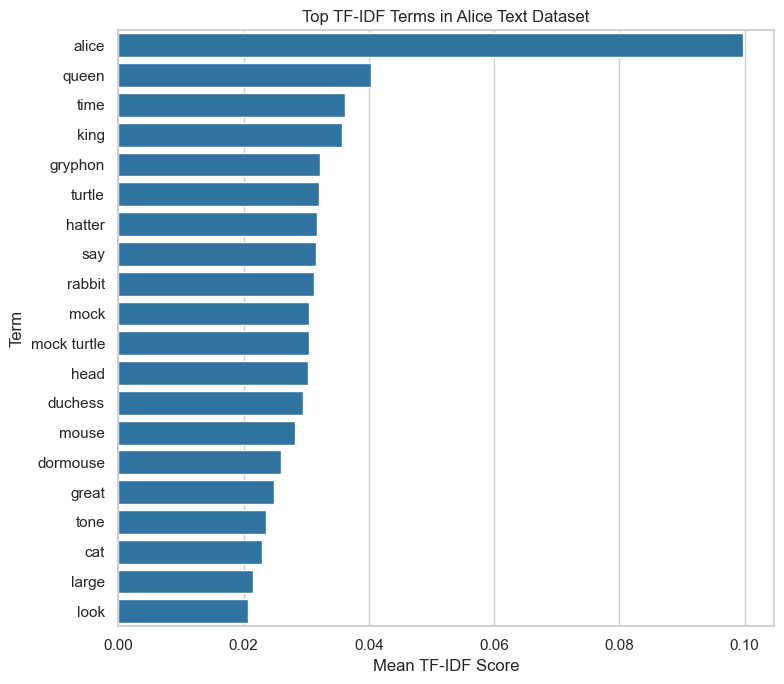

,term,mean_tfidf
3,alice,0.099687
205,queen,0.040293
261,time,0.036226
147,king,0.035752
109,gryphon,0.032248
273,turtle,0.032055
122,hatter,0.031705
225,say,0.031637
208,rabbit,0.031184
174,mock,0.030466


In [59]:
# =========================
# Top TF-IDF terms
# =========================

mean_tfidf = text_tfidf_dense.mean(axis=0)

top_terms_df = pd.DataFrame({
    "term": tfidf_feature_names,
    "mean_tfidf": mean_tfidf
}).sort_values("mean_tfidf", ascending=False).head(30)

save_dataframe(top_terms_df, TABLE_DIR / "03_text_top_tfidf_terms.csv")

plt.figure(figsize=(8, 7))
sns.barplot(data=top_terms_df.head(20), y="term", x="mean_tfidf")
plt.title("Top TF-IDF Terms in Alice Text Dataset")
plt.xlabel("Mean TF-IDF Score")
plt.ylabel("Term")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_text_top_tfidf_terms.png", dpi=220)
plt.show()

top_terms_df.head(20)

In [60]:
# =========================
# Method 2: Pretrained sentence embeddings
# =========================

TEXT_EMBEDDING_METHOD = "fallback_tfidf_svd"

try:
    from sentence_transformers import SentenceTransformer

    sentence_model = SentenceTransformer("all-MiniLM-L6-v2")
    text_embedding_matrix = sentence_model.encode(
        text_corpus,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    TEXT_EMBEDDING_METHOD = "all-MiniLM-L6-v2"

except Exception as e:
    print("SentenceTransformer unavailable or model could not be loaded.")
    print("Fallback:", e)

    svd_components = min(100, text_tfidf_dense.shape[1] - 1)
    svd = TruncatedSVD(n_components=svd_components, random_state=42)
    text_embedding_matrix = svd.fit_transform(text_tfidf_dense)
    text_embedding_matrix = StandardScaler().fit_transform(text_embedding_matrix)

print("Text embedding method:", TEXT_EMBEDDING_METHOD)
print("Text embedding matrix shape:", text_embedding_matrix.shape)

text_embedding_df = pd.DataFrame(
    text_embedding_matrix,
    columns=[f"text_emb_{i:03d}" for i in range(text_embedding_matrix.shape[1])]
)

text_embedding_output_df = pd.concat(
    [
        text_df[["text_id", "chapter_title", "type", TEXT_COLUMN]].reset_index(drop=True),
        text_embedding_df.reset_index(drop=True)
    ],
    axis=1
)

save_dataframe(text_embedding_output_df, TEXT_VECTOR_DIR / "text_embedding_vectorised.csv")
save_array(text_embedding_matrix, TEXT_VECTOR_DIR / "text_embedding_matrix.npy")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12113.77it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 9/9 [00:00<00:00, 102.73it/s]

Text embedding method: all-MiniLM-L6-v2
Text embedding matrix shape: (288, 384)
Saved: ..\..\data\processed\text_vectors\text_embedding_vectorised.csv
Saved: ..\..\data\processed\text_vectors\text_embedding_matrix.npy


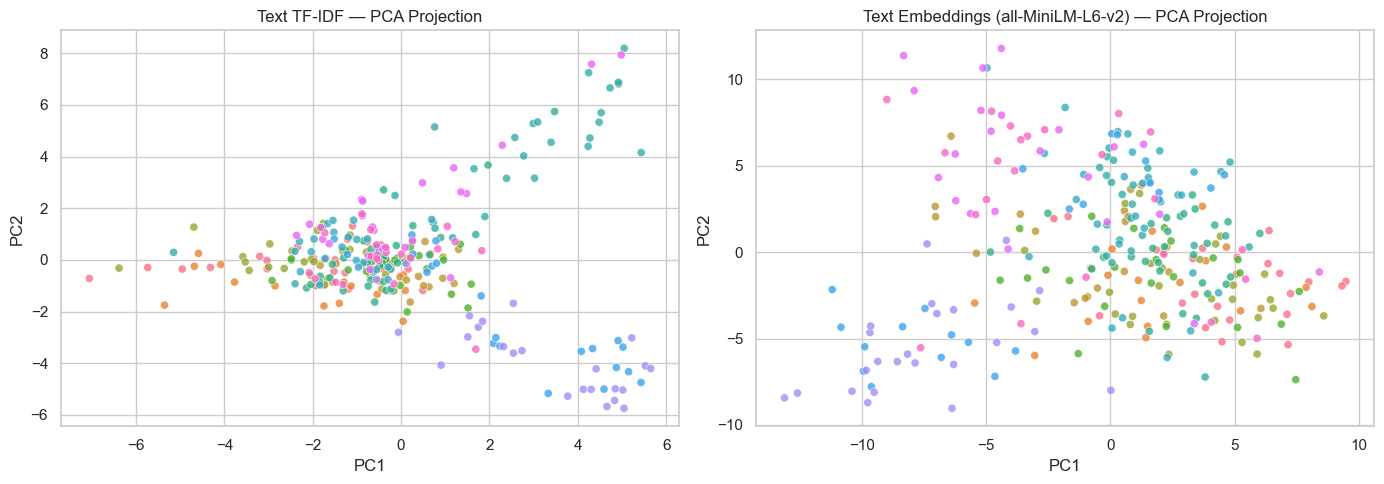

Saved: ..\..\outputs\tables\03_text_pca_variance_comparison.csv


,method,PC1_variance,PC2_variance
0,TF-IDF,0.018366,0.017539
1,all-MiniLM-L6-v2,0.054861,0.046121


In [61]:
# =========================
# Text vectorisation comparison: PCA
# =========================

tfidf_scaled = StandardScaler().fit_transform(text_tfidf_dense)
embedding_scaled = StandardScaler().fit_transform(text_embedding_matrix)

tfidf_pca_df, tfidf_pca = pca_dataframe(tfidf_scaled, labels=text_labels)
embedding_pca_df, embedding_pca = pca_dataframe(embedding_scaled, labels=text_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=tfidf_pca_df,
    x="PC1",
    y="PC2",
    hue="label",
    ax=axes[0],
    legend=False,
    s=35,
    alpha=0.8
)
axes[0].set_title("Text TF-IDF — PCA Projection")

sns.scatterplot(
    data=embedding_pca_df,
    x="PC1",
    y="PC2",
    hue="label",
    ax=axes[1],
    legend=False,
    s=35,
    alpha=0.8
)
axes[1].set_title(f"Text Embeddings ({TEXT_EMBEDDING_METHOD}) — PCA Projection")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_text_vectorisation_pca_comparison.png", dpi=220)
plt.show()

text_pca_variance_df = pd.DataFrame({
    "method": ["TF-IDF", TEXT_EMBEDDING_METHOD],
    "PC1_variance": [tfidf_pca.explained_variance_ratio_[0], embedding_pca.explained_variance_ratio_[0]],
    "PC2_variance": [tfidf_pca.explained_variance_ratio_[1], embedding_pca.explained_variance_ratio_[1]]
})

save_dataframe(text_pca_variance_df, TABLE_DIR / "03_text_pca_variance_comparison.csv")
text_pca_variance_df

Saved: ..\..\outputs\tables\03_text_clustering_comparison.csv


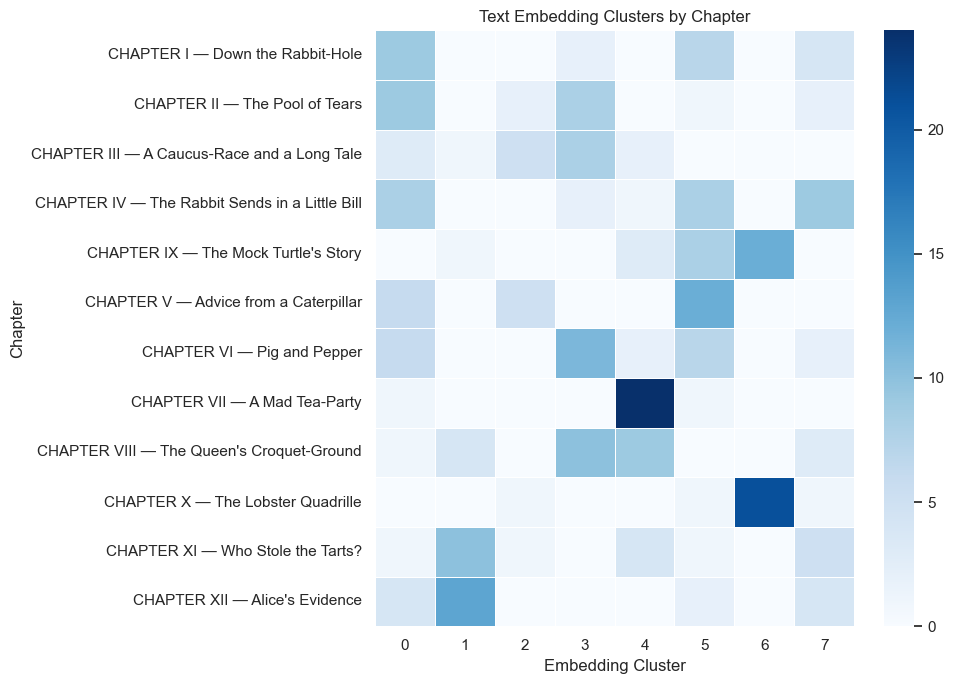

,method,n_clusters,silhouette_score
0,TF-IDF,8,-0.008620
1,all-MiniLM-L6-v2,8,0.038866


In [62]:
# =========================
# Text clustering comparison
# =========================

TEXT_N_CLUSTERS = 8

tfidf_clusters, tfidf_silhouette = run_kmeans(tfidf_scaled, n_clusters=TEXT_N_CLUSTERS)
embedding_clusters, embedding_silhouette = run_kmeans(embedding_scaled, n_clusters=TEXT_N_CLUSTERS)

text_cluster_comparison_df = pd.DataFrame({
    "method": ["TF-IDF", TEXT_EMBEDDING_METHOD],
    "n_clusters": [TEXT_N_CLUSTERS, TEXT_N_CLUSTERS],
    "silhouette_score": [tfidf_silhouette, embedding_silhouette]
})

save_dataframe(text_cluster_comparison_df, TABLE_DIR / "03_text_clustering_comparison.csv")

text_df["tfidf_cluster"] = tfidf_clusters
text_df["embedding_cluster"] = embedding_clusters

cluster_chapter_table = pd.crosstab(text_df["chapter_title"], text_df["embedding_cluster"])

plt.figure(figsize=(10, 7))
sns.heatmap(cluster_chapter_table, cmap="Blues", linewidths=0.5)
plt.title("Text Embedding Clusters by Chapter")
plt.xlabel("Embedding Cluster")
plt.ylabel("Chapter")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_text_embedding_cluster_heatmap.png", dpi=220)
plt.show()

text_cluster_comparison_df

### Text Retrieval Comparison

The same query terms are tested against TF-IDF and sentence embeddings.  
This makes the difference between keyword matching and semantic matching easier to interpret.

TF-IDF tends to retrieve passages containing literal words, while embeddings are more likely to retrieve semantically related passages.

In [63]:
# =========================
# Query retrieval comparison
# =========================

query_terms = [
    "rabbit hole",
    "mad tea party",
    "queen of hearts",
    "dream",
    "door",
    "time",
    "mushroom"
]

def retrieve_tfidf(query, top_k=3):
    q_vec = tfidf_vectorizer.transform([query]).toarray()
    sims = cosine_similarity(q_vec, text_tfidf_dense)[0]
    idxs = np.argsort(sims)[::-1][:top_k]

    rows = []
    for idx in idxs:
        rows.append({
            "method": "TF-IDF",
            "query": query,
            "rank": len(rows) + 1,
            "score": sims[idx],
            "text_id": text_df.iloc[idx]["text_id"],
            "chapter_title": text_df.iloc[idx]["chapter_title"],
            "text_preview": text_df.iloc[idx][TEXT_COLUMN][:220]
        })
    return rows


def retrieve_embedding(query, top_k=3):
    if TEXT_EMBEDDING_METHOD == "all-MiniLM-L6-v2":
        q_vec = sentence_model.encode([query], normalize_embeddings=True)
    else:
        q_tfidf = tfidf_vectorizer.transform([query]).toarray()
        q_vec = svd.transform(q_tfidf)
        q_vec = StandardScaler().fit(text_embedding_matrix).transform(q_vec)

    sims = cosine_similarity(q_vec, text_embedding_matrix)[0]
    idxs = np.argsort(sims)[::-1][:top_k]

    rows = []
    for idx in idxs:
        rows.append({
            "method": TEXT_EMBEDDING_METHOD,
            "query": query,
            "rank": len(rows) + 1,
            "score": sims[idx],
            "text_id": text_df.iloc[idx]["text_id"],
            "chapter_title": text_df.iloc[idx]["chapter_title"],
            "text_preview": text_df.iloc[idx][TEXT_COLUMN][:220]
        })
    return rows


retrieval_rows = []

for query in query_terms:
    retrieval_rows.extend(retrieve_tfidf(query, top_k=3))
    retrieval_rows.extend(retrieve_embedding(query, top_k=3))

text_retrieval_df = pd.DataFrame(retrieval_rows)

save_dataframe(text_retrieval_df, TABLE_DIR / "03_text_retrieval_comparison.csv")
text_retrieval_df.head(20)

Saved: ..\..\outputs\tables\03_text_retrieval_comparison.csv


,method,query,rank,score,text_id,chapter_title,text_preview
0,TF-IDF,rabbit hole,1,0.587769,text_0179,CHAPTER VIII — The Queen's Croquet-Ground,"She was walking by the White Rabbit, who was p..."
1,TF-IDF,rabbit hole,2,0.524574,text_0002,CHAPTER I — Down the Rabbit-Hole,I shall be late!' (when she thought it over af...
2,TF-IDF,rabbit hole,3,0.517396,text_0001,CHAPTER I — Down the Rabbit-Hole,There was nothing so VERY remarkable in that; ...
3,all-MiniLM-L6-v2,rabbit hole,1,0.501153,text_0003,CHAPTER I — Down the Rabbit-Hole,"In another moment down went Alice after it, ne..."
4,all-MiniLM-L6-v2,rabbit hole,2,0.484298,text_0002,CHAPTER I — Down the Rabbit-Hole,I shall be late!' (when she thought it over af...
5,all-MiniLM-L6-v2,rabbit hole,3,0.456522,text_0074,CHAPTER IV — The Rabbit Sends in a Little Bill,Alice heard it say to itself `Then I'll go rou...
6,TF-IDF,mad tea party,1,0.565497,text_0043,CHAPTER II — The Pool of Tears,"Alice led the way, and the whole party swam to..."
7,TF-IDF,mad tea party,2,0.475625,text_0137,CHAPTER VI — Pig and Pepper,You're mad.' `How do you know I'm mad?' said A...
8,TF-IDF,mad tea party,3,0.408777,text_0136,CHAPTER VI — Pig and Pepper,"`--so long as I get SOMEWHERE,' Alice added as..."
9,all-MiniLM-L6-v2,mad tea party,1,0.513242,text_0166,CHAPTER VII — A Mad Tea-Party,`It's the stupidest tea-party I ever was at in...


## 4. Image Vectorisation

The image dataset is vectorised using a handcrafted visual feature method.

The handcrafted feature vector includes:

- image size and aspect ratio
- RGB colour statistics
- RGB colour histograms

This method is intentionally interpretable.  
It captures colour, brightness and basic visual composition, which are useful for linking image categories to material and atmosphere in the design workflows.

An optional pretrained image embedding section is also included. If a CLIP model is available locally, it can generate semantic image embeddings for cross-modal analysis.

In [64]:
# =========================
# Prepare image metadata
# =========================

RAW_IMAGE_DIR = DATA_DIR / "raw" / "images"

def resolve_image_metadata_path(row):
    if "resolved_path" in row and pd.notna(row["resolved_path"]):
        p = Path(str(row["resolved_path"]))
        if p.exists():
            return p

    if "file_path" in row and pd.notna(row["file_path"]):
        p = Path(str(row["file_path"]))
        if p.exists():
            return p
        p2 = PROJECT_ROOT / p
        if p2.exists():
            return p2

    if "file_name" in row and pd.notna(row["file_name"]):
        p = RAW_IMAGE_DIR / str(row["file_name"])
        if p.exists():
            return p

    return None

image_df["resolved_path"] = image_df.apply(resolve_image_metadata_path, axis=1)

valid_image_df = image_df[image_df["resolved_path"].notna()].copy()

print("Valid images for vectorisation:", len(valid_image_df))
valid_image_df[["file_name", "category", "resolved_path"]].head()

Valid images for vectorisation: 278


,file_name,category,resolved_path
0,img_0002.jpg,alice,..\..\data\raw\images\img_0002.jpg
1,img_0007.jpg,alice,..\..\data\raw\images\img_0007.jpg
2,img_0015.jpg,alice,..\..\data\raw\images\img_0015.jpg
3,img_0018.jpg,alice,..\..\data\raw\images\img_0018.jpg
4,img_0022.jpg,alice,..\..\data\raw\images\img_0022.jpg


In [65]:
# =========================
# Handcrafted image feature extraction
# =========================

def extract_image_features(image_path, hist_bins=8):
    """
    Extract interpretable image features:
    - RGB means and standard deviations
    - RGB histograms
    - image size and aspect ratio
    """
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        width, height = img.size

        img_small = img.resize((128, 128))
        arr = np.asarray(img_small).astype(np.float32) / 255.0

    features = {}

    features["width"] = width
    features["height"] = height
    features["aspect_ratio"] = max(width / height, height / width)

    channel_names = ["r", "g", "b"]

    for i, channel in enumerate(channel_names):
        channel_arr = arr[:, :, i]

        features[f"{channel}_mean"] = float(channel_arr.mean())
        features[f"{channel}_std"] = float(channel_arr.std())

        hist, _ = np.histogram(channel_arr, bins=hist_bins, range=(0, 1), density=True)

        for j, value in enumerate(hist):
            features[f"{channel}_hist_{j:02d}"] = float(value)

    features["brightness_mean"] = float(arr.mean())
    features["brightness_std"] = float(arr.std())

    return features


image_feature_records = []

for _, row in valid_image_df.iterrows():
    try:
        feats = extract_image_features(row["resolved_path"])
        feats.update({
            "image_id": row.get("image_id", Path(row["resolved_path"]).stem),
            "file_name": row.get("file_name", Path(row["resolved_path"]).name),
            "category": row.get("category", "unknown"),
            "resolved_path": str(row["resolved_path"])
        })
        image_feature_records.append(feats)
    except Exception as e:
        print("Failed:", row.get("file_name"), e)

image_vectorised_df = pd.DataFrame(image_feature_records)

feature_cols = [
    c for c in image_vectorised_df.columns
    if c not in ["image_id", "file_name", "category", "resolved_path"]
]

image_feature_matrix = image_vectorised_df[feature_cols].fillna(0).values

print("Image vectorised shape:", image_vectorised_df.shape)
print("Image feature matrix:", image_feature_matrix.shape)

save_dataframe(image_vectorised_df, PROCESSED_DIR / "image_vectorised.csv")
save_dataframe(image_vectorised_df, IMAGE_VECTOR_DIR / "image_handcrafted_vectorised.csv")
save_array(image_feature_matrix, IMAGE_VECTOR_DIR / "image_handcrafted_matrix.npy")

image_vectorised_df.head()

Image vectorised shape: (278, 39)
Image feature matrix: (278, 35)
Saved: ..\..\data\processed\image_vectorised.csv
Saved: ..\..\data\processed\image_vectors\image_handcrafted_vectorised.csv
Saved: ..\..\data\processed\image_vectors\image_handcrafted_matrix.npy


,width,height,aspect_ratio,r_mean,r_std,r_hist_00,r_hist_01,r_hist_02,r_hist_03,r_hist_04,...,b_hist_04,b_hist_05,b_hist_06,b_hist_07,brightness_mean,brightness_std,image_id,file_name,category,resolved_path
0,650,650,1.000000,0.295443,0.150543,1.319824,1.985840,2.276367,1.567871,0.678711,...,0.456543,0.184570,0.000000,0.000000,0.259590,0.166799,img_0002,img_0002.jpg,alice,..\..\data\raw\images\img_0002.jpg
1,650,650,1.000000,0.501674,0.210306,0.120117,0.677734,1.717773,1.745605,1.593750,...,1.332520,0.932129,0.681641,0.378906,0.493872,0.210693,img_0007,img_0007.jpg,alice,..\..\data\raw\images\img_0007.jpg
2,592,800,1.351351,0.865729,0.131472,0.000000,0.003418,0.017578,0.115234,0.391602,...,0.921387,0.923340,2.017578,3.768066,0.838525,0.156264,img_0015,img_0015.jpg,alice,..\..\data\raw\images\img_0015.jpg
3,682,1023,1.500000,0.929826,0.066575,0.000000,0.000977,0.004883,0.017578,0.050293,...,0.057129,0.229980,0.894043,6.791016,0.921991,0.067073,img_0018,img_0018.jpg,alice,..\..\data\raw\images\img_0018.jpg
4,682,1023,1.500000,0.930910,0.064052,0.000000,0.001953,0.003418,0.017578,0.044434,...,0.055664,0.189941,0.877930,6.849609,0.923074,0.064590,img_0022,img_0022.jpg,alice,..\..\data\raw\images\img_0022.jpg


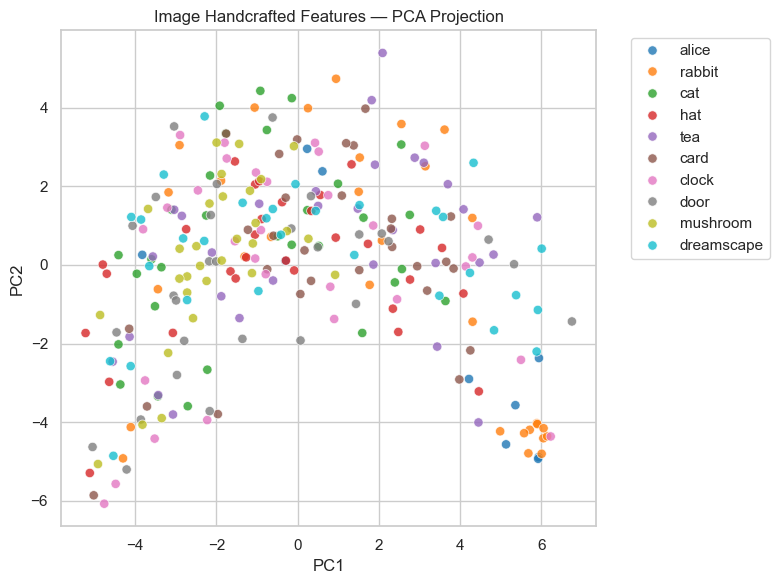

Saved: ..\..\outputs\tables\03_image_pca_variance.csv


,component,explained_variance
0,PC1,0.280173
1,PC2,0.163386


In [66]:
# =========================
# Image feature visualisation
# =========================

image_scaled = StandardScaler().fit_transform(image_feature_matrix)

image_pca_df, image_pca = pca_dataframe(
    image_scaled,
    labels=image_vectorised_df["category"]
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=image_pca_df,
    x="PC1",
    y="PC2",
    hue="label",
    s=45,
    alpha=0.8
)
plt.title("Image Handcrafted Features — PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_image_handcrafted_pca_projection.png", dpi=220)
plt.show()

image_pca_variance_df = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance": image_pca.explained_variance_ratio_
})

save_dataframe(image_pca_variance_df, TABLE_DIR / "03_image_pca_variance.csv")
image_pca_variance_df

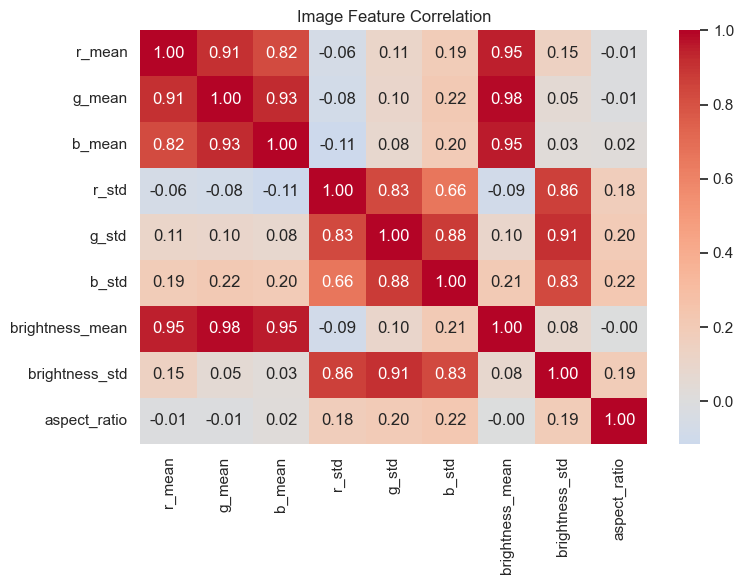

In [67]:
# =========================
# Image feature correlation heatmap
# =========================

compact_image_features = [
    "r_mean", "g_mean", "b_mean",
    "r_std", "g_std", "b_std",
    "brightness_mean", "brightness_std",
    "aspect_ratio"
]

available_compact_features = [
    c for c in compact_image_features
    if c in image_vectorised_df.columns
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    image_vectorised_df[available_compact_features].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Image Feature Correlation")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_image_feature_correlation.png", dpi=220)
plt.show()

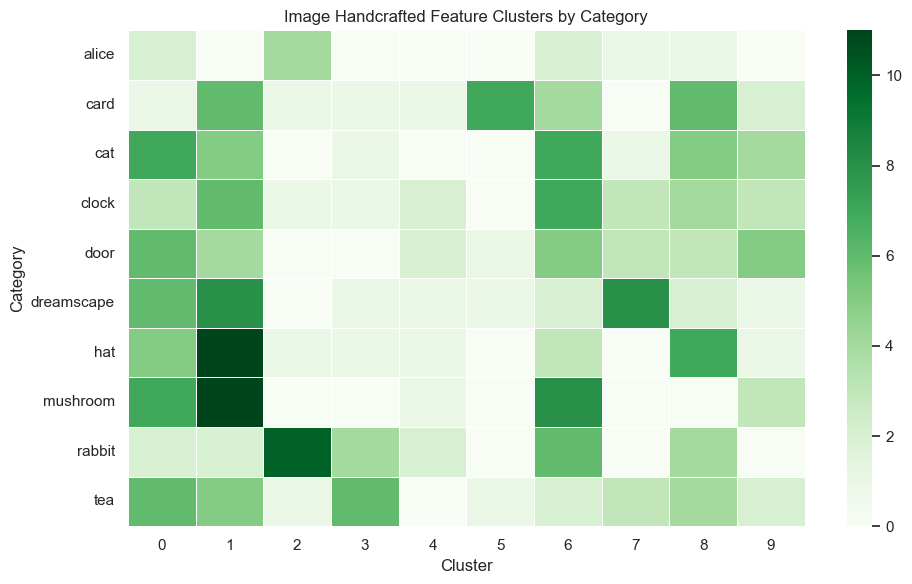

Saved: ..\..\outputs\tables\03_image_clustering_summary.csv


,method,n_clusters,silhouette_score
0,handcrafted_colour_size_features,10,0.170996


In [68]:
# =========================
# Image clustering
# =========================

IMAGE_N_CLUSTERS = 10

image_clusters, image_silhouette = run_kmeans(image_scaled, n_clusters=IMAGE_N_CLUSTERS)

image_vectorised_df["image_cluster"] = image_clusters

image_cluster_table = pd.crosstab(
    image_vectorised_df["category"],
    image_vectorised_df["image_cluster"]
)

plt.figure(figsize=(10, 6))
sns.heatmap(image_cluster_table, cmap="Greens", linewidths=0.5)
plt.title("Image Handcrafted Feature Clusters by Category")
plt.xlabel("Cluster")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_image_cluster_heatmap.png", dpi=220)
plt.show()

image_clustering_summary = pd.DataFrame({
    "method": ["handcrafted_colour_size_features"],
    "n_clusters": [IMAGE_N_CLUSTERS],
    "silhouette_score": [image_silhouette]
})

save_dataframe(image_clustering_summary, TABLE_DIR / "03_image_clustering_summary.csv")
image_clustering_summary

### Optional: Pretrained CLIP Image Embeddings

If the local environment has `sentence-transformers` and a CLIP model available, this section can generate pretrained image embeddings.

This optional step is useful for semantic image comparison because CLIP connects visual content with language.

If the model is unavailable, the notebook continues using the handcrafted image features.

In [69]:
# =========================
# Optional pretrained CLIP image embeddings
# =========================

USE_IMAGE_CLIP = False
image_clip_matrix = None
IMAGE_CLIP_METHOD = "not_available"

try:
    from sentence_transformers import SentenceTransformer
    clip_model = SentenceTransformer("clip-ViT-B-32")

    image_paths = [str(p) for p in image_vectorised_df["resolved_path"]]
    image_objects = [Image.open(p).convert("RGB") for p in image_paths]

    image_clip_matrix = clip_model.encode(
        image_objects,
        show_progress_bar=True,
        normalize_embeddings=True
    )

    USE_IMAGE_CLIP = True
    IMAGE_CLIP_METHOD = "clip-ViT-B-32"

    image_clip_df = pd.DataFrame(
        image_clip_matrix,
        columns=[f"image_clip_{i:03d}" for i in range(image_clip_matrix.shape[1])]
    )

    image_clip_output_df = pd.concat(
        [
            image_vectorised_df[["image_id", "file_name", "category", "resolved_path"]].reset_index(drop=True),
            image_clip_df.reset_index(drop=True)
        ],
        axis=1
    )

    save_dataframe(image_clip_output_df, IMAGE_VECTOR_DIR / "image_clip_vectorised.csv")
    save_array(image_clip_matrix, IMAGE_VECTOR_DIR / "image_clip_matrix.npy")

    print("CLIP image embeddings generated:", image_clip_matrix.shape)

except Exception as e:
    print("Pretrained CLIP image embedding unavailable.")
    print("Continuing with handcrafted image features.")
    print("Reason:", e)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 11207.49it/s]
CLIPModel LOAD REPORT from: sentence-transformers/clip-ViT-B-32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 9/9 [00:03<00:00,  2.53it/s]


Saved: ..\..\data\processed\image_vectors\image_clip_vectorised.csv
Saved: ..\..\data\processed\image_vectors\image_clip_matrix.npy
CLIP image embeddings generated: (278, 512)


## 5. Audio Vectorisation

The audio dataset is vectorised using two methods:

### Method 1 — Basic Audio Descriptors

Basic descriptors include duration, RMS energy, spectral centroid, spectral bandwidth and zero-crossing rate.  
These features are interpretable and easy to map to animation parameters.

### Method 2 — MFCC Features

MFCCs capture spectral and timbral qualities of sound.  
They are less immediately interpretable but better at representing sound texture and acoustic character.

This comparison supports the later use of audio as behavioural input for TouchDesigner point-cloud motion.

In [70]:
# =========================
# Prepare audio metadata
# =========================

RAW_AUDIO_DIR = DATA_DIR / "raw" / "audio"

def resolve_audio_metadata_path(row):
    if "resolved_path" in row and pd.notna(row["resolved_path"]):
        p = Path(str(row["resolved_path"]))
        if p.exists():
            return p

    if "file_path" in row and pd.notna(row["file_path"]):
        p = Path(str(row["file_path"]))
        if p.exists():
            return p
        p2 = PROJECT_ROOT / p
        if p2.exists():
            return p2

    if "file_name" in row and pd.notna(row["file_name"]):
        p = RAW_AUDIO_DIR / str(row["file_name"])
        if p.exists():
            return p

    return None

audio_df["resolved_path"] = audio_df.apply(resolve_audio_metadata_path, axis=1)

valid_audio_df = audio_df[audio_df["resolved_path"].notna()].copy()

print("Valid audio files for vectorisation:", len(valid_audio_df))
valid_audio_df[["file_name", "category", "resolved_path"]].head()

Valid audio files for vectorisation: 270


,file_name,category,resolved_path
0,audio_0350.mp3,ambient,..\..\data\raw\audio\audio_0350.mp3
1,audio_0351.mp3,ambient,..\..\data\raw\audio\audio_0351.mp3
2,audio_0352.mp3,ambient,..\..\data\raw\audio\audio_0352.mp3
3,audio_0353.mp3,ambient,..\..\data\raw\audio\audio_0353.mp3
4,audio_0354.mp3,ambient,..\..\data\raw\audio\audio_0354.mp3


In [71]:
# =========================
# Extract audio features
# =========================

try:
    import librosa
except Exception as e:
    raise ImportError(
        "librosa is required for audio vectorisation. "
        "Install it with: pip install librosa"
    ) from e


def extract_audio_features(audio_path, max_duration=30, sr=22050, n_mfcc=13):
    """
    Extract basic audio descriptors and MFCC statistics.
    """
    y, sr = librosa.load(audio_path, sr=sr, mono=True, duration=max_duration)

    if len(y) == 0:
        raise ValueError("Empty audio signal")

    duration = librosa.get_duration(y=y, sr=sr)

    rms = librosa.feature.rms(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]

    basic = {
        "duration": duration,
        "rms_mean": float(np.mean(rms)),
        "rms_std": float(np.std(rms)),
        "zcr_mean": float(np.mean(zcr)),
        "zcr_std": float(np.std(zcr)),
        "spectral_centroid_mean": float(np.mean(centroid)),
        "spectral_centroid_std": float(np.std(centroid)),
        "spectral_bandwidth_mean": float(np.mean(bandwidth)),
        "spectral_bandwidth_std": float(np.std(bandwidth)),
        "spectral_rolloff_mean": float(np.mean(rolloff)),
        "spectral_rolloff_std": float(np.std(rolloff)),
    }

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    mfcc_features = {}

    for i in range(n_mfcc):
        mfcc_features[f"mfcc_{i+1:02d}_mean"] = float(np.mean(mfcc[i]))
        mfcc_features[f"mfcc_{i+1:02d}_std"] = float(np.std(mfcc[i]))

    return basic, mfcc_features


audio_basic_records = []
audio_mfcc_records = []

for _, row in valid_audio_df.iterrows():
    audio_path = Path(row["resolved_path"])

    try:
        basic, mfcc = extract_audio_features(audio_path)

        base_info = {
            "audio_id": row.get("audio_id", audio_path.stem),
            "file_name": row.get("file_name", audio_path.name),
            "category": row.get("category", "unknown"),
            "resolved_path": str(audio_path)
        }

        audio_basic_records.append({**base_info, **basic})
        audio_mfcc_records.append({**base_info, **mfcc})

    except Exception as e:
        print("Audio feature extraction failed:", audio_path.name, e)

audio_basic_df = pd.DataFrame(audio_basic_records)
audio_mfcc_df = pd.DataFrame(audio_mfcc_records)

print("Basic audio features:", audio_basic_df.shape)
print("MFCC audio features:", audio_mfcc_df.shape)

save_dataframe(audio_basic_df, PROCESSED_DIR / "audio_basic_vectorised.csv")
save_dataframe(audio_mfcc_df, PROCESSED_DIR / "audio_mfcc_vectorised.csv")

save_dataframe(audio_basic_df, AUDIO_VECTOR_DIR / "audio_basic_vectorised.csv")
save_dataframe(audio_mfcc_df, AUDIO_VECTOR_DIR / "audio_mfcc_vectorised.csv")

Basic audio features: (270, 15)
MFCC audio features: (270, 30)
Saved: ..\..\data\processed\audio_basic_vectorised.csv
Saved: ..\..\data\processed\audio_mfcc_vectorised.csv
Saved: ..\..\data\processed\audio_vectors\audio_basic_vectorised.csv
Saved: ..\..\data\processed\audio_vectors\audio_mfcc_vectorised.csv


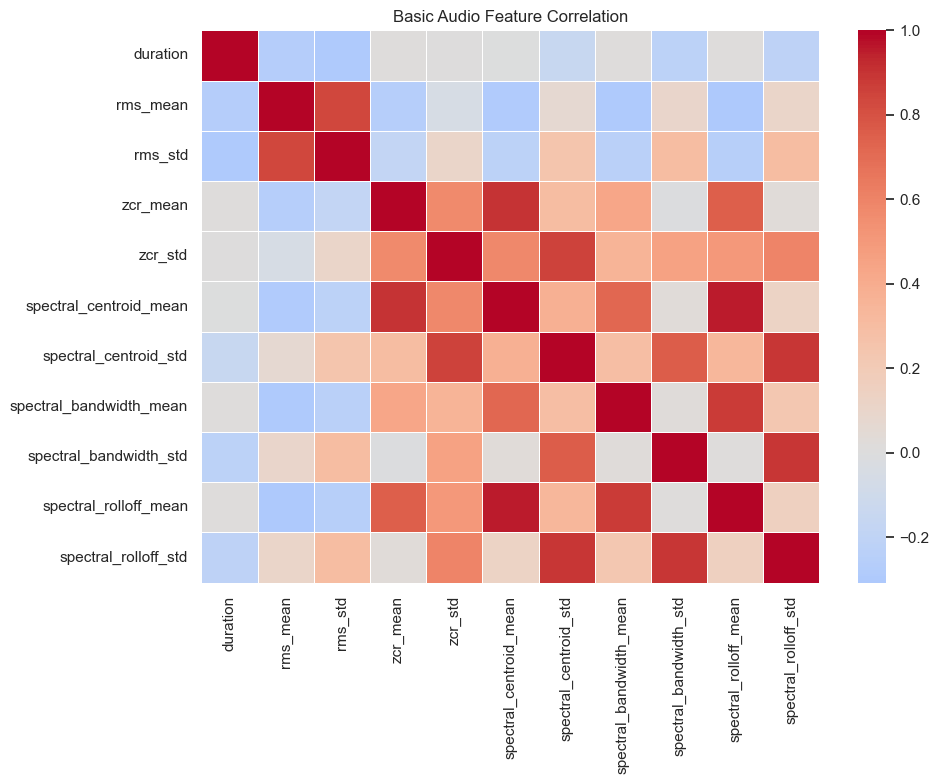

In [72]:
# =========================
# Audio basic feature correlation
# =========================

basic_feature_cols = [
    c for c in audio_basic_df.columns
    if c not in ["audio_id", "file_name", "category", "resolved_path"]
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    audio_basic_df[basic_feature_cols].corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Basic Audio Feature Correlation")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_audio_basic_feature_correlation.png", dpi=220)
plt.show()

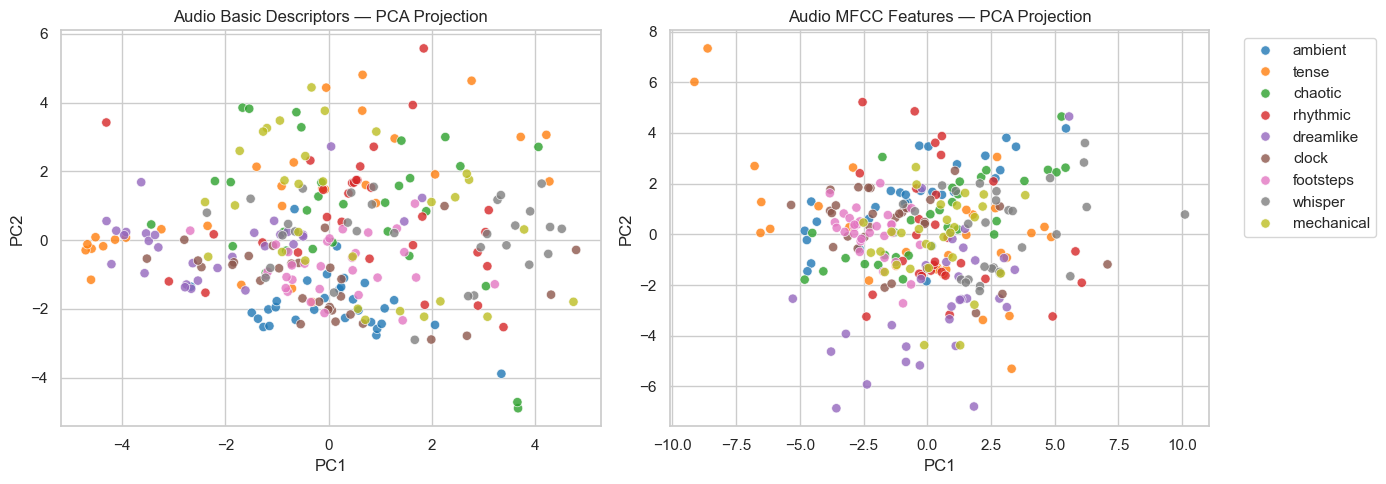

Saved: ..\..\outputs\tables\03_audio_pca_variance_comparison.csv


,method,PC1_variance,PC2_variance
0,basic_descriptors,0.399862,0.282563
1,mfcc_features,0.308039,0.169780


In [73]:
# =========================
# Audio feature PCA comparison
# =========================

basic_matrix = audio_basic_df[basic_feature_cols].fillna(0).values
basic_scaled = StandardScaler().fit_transform(basic_matrix)

mfcc_feature_cols = [
    c for c in audio_mfcc_df.columns
    if c not in ["audio_id", "file_name", "category", "resolved_path"]
]

mfcc_matrix = audio_mfcc_df[mfcc_feature_cols].fillna(0).values
mfcc_scaled = StandardScaler().fit_transform(mfcc_matrix)

basic_pca_df, basic_pca = pca_dataframe(
    basic_scaled,
    labels=audio_basic_df["category"]
)

mfcc_pca_df, mfcc_pca = pca_dataframe(
    mfcc_scaled,
    labels=audio_mfcc_df["category"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=basic_pca_df,
    x="PC1",
    y="PC2",
    hue="label",
    s=45,
    alpha=0.8,
    ax=axes[0],
    legend=False
)
axes[0].set_title("Audio Basic Descriptors — PCA Projection")

sns.scatterplot(
    data=mfcc_pca_df,
    x="PC1",
    y="PC2",
    hue="label",
    s=45,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title("Audio MFCC Features — PCA Projection")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_audio_vectorisation_pca_comparison.png", dpi=220)
plt.show()

audio_pca_variance_df = pd.DataFrame({
    "method": ["basic_descriptors", "mfcc_features"],
    "PC1_variance": [basic_pca.explained_variance_ratio_[0], mfcc_pca.explained_variance_ratio_[0]],
    "PC2_variance": [basic_pca.explained_variance_ratio_[1], mfcc_pca.explained_variance_ratio_[1]]
})

save_dataframe(audio_pca_variance_df, TABLE_DIR / "03_audio_pca_variance_comparison.csv")
audio_pca_variance_df

Saved: ..\..\outputs\tables\03_audio_clustering_comparison.csv


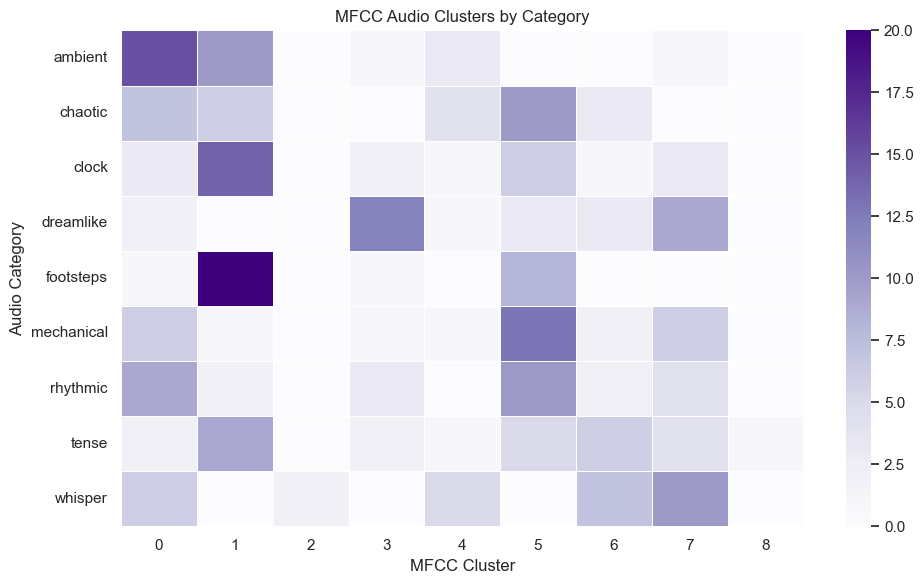

,method,n_clusters,silhouette_score
0,basic_audio_descriptors,9,0.199004
1,mfcc_features,9,0.107957


In [74]:
# =========================
# Audio clustering comparison
# =========================

AUDIO_N_CLUSTERS = 9

basic_clusters, basic_silhouette = run_kmeans(basic_scaled, n_clusters=AUDIO_N_CLUSTERS)
mfcc_clusters, mfcc_silhouette = run_kmeans(mfcc_scaled, n_clusters=AUDIO_N_CLUSTERS)

audio_basic_df["basic_cluster"] = basic_clusters
audio_mfcc_df["mfcc_cluster"] = mfcc_clusters

audio_clustering_comparison_df = pd.DataFrame({
    "method": ["basic_audio_descriptors", "mfcc_features"],
    "n_clusters": [AUDIO_N_CLUSTERS, AUDIO_N_CLUSTERS],
    "silhouette_score": [basic_silhouette, mfcc_silhouette]
})

save_dataframe(audio_clustering_comparison_df, TABLE_DIR / "03_audio_clustering_comparison.csv")

mfcc_cluster_table = pd.crosstab(audio_mfcc_df["category"], audio_mfcc_df["mfcc_cluster"])

plt.figure(figsize=(10, 6))
sns.heatmap(mfcc_cluster_table, cmap="Purples", linewidths=0.5)
plt.title("MFCC Audio Clusters by Category")
plt.xlabel("MFCC Cluster")
plt.ylabel("Audio Category")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "09_audio_mfcc_cluster_heatmap.png", dpi=220)
plt.show()

audio_clustering_comparison_df

## 6. Cross-Dataset Comparison and Design Relevance

This section summarises how each vectorisation method contributes to the design workflow.

The goal is not to force all datasets into a single universal vector space, but to understand what each feature type is good for:

- Text features help structure narrative and prompt generation.
- Image features help describe visual style, colour and atmosphere.
- Audio features help drive motion, rhythm and instability.

Saved: ..\..\outputs\tables\03_feature_dimension_summary.csv


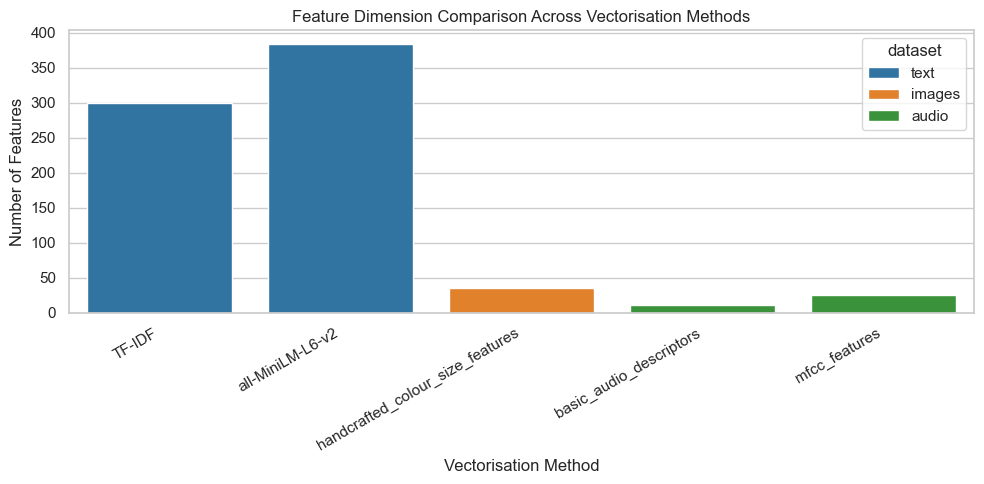

,dataset,method,feature_dimensions,design_role
0,text,TF-IDF,300,interpretable keywords and themes
1,text,all-MiniLM-L6-v2,384,semantic narrative similarity
2,images,handcrafted_colour_size_features,35,"visual colour, texture and atmosphere"
3,audio,basic_audio_descriptors,11,motion intensity and direct TD parameters
4,audio,mfcc_features,26,sound texture and timbral grouping


In [75]:
# =========================
# Feature dimension summary
# =========================

feature_dimension_summary = pd.DataFrame({
    "dataset": [
        "text",
        "text",
        "images",
        "audio",
        "audio"
    ],
    "method": [
        "TF-IDF",
        TEXT_EMBEDDING_METHOD,
        "handcrafted_colour_size_features",
        "basic_audio_descriptors",
        "mfcc_features"
    ],
    "feature_dimensions": [
        text_tfidf_dense.shape[1],
        text_embedding_matrix.shape[1],
        image_feature_matrix.shape[1],
        basic_matrix.shape[1],
        mfcc_matrix.shape[1]
    ],
    "design_role": [
        "interpretable keywords and themes",
        "semantic narrative similarity",
        "visual colour, texture and atmosphere",
        "motion intensity and direct TD parameters",
        "sound texture and timbral grouping"
    ]
})

save_dataframe(feature_dimension_summary, TABLE_DIR / "03_feature_dimension_summary.csv")

plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_dimension_summary,
    x="method",
    y="feature_dimensions",
    hue="dataset"
)
plt.title("Feature Dimension Comparison Across Vectorisation Methods")
plt.xlabel("Vectorisation Method")
plt.ylabel("Number of Features")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "10_feature_dimension_comparison.png", dpi=220)
plt.show()

feature_dimension_summary

In [76]:
# =========================
# Design mapping summary table
# =========================

design_mapping_summary = pd.DataFrame({
    "dataset": [
        "Text",
        "Images",
        "Audio",
        "Text + Images",
        "Audio + Point Clouds"
    ],
    "processed_feature": [
        "TF-IDF terms and sentence embeddings",
        "Colour, size, aspect ratio and optional CLIP embeddings",
        "Basic audio descriptors and MFCCs",
        "Semantic and visual categories",
        "RMS / spectral / MFCC characteristics"
    ],
    "design_translation": [
        "Narrative themes and prompt generation",
        "Texture selection, visual atmosphere and object references",
        "Rhythm, instability and behavioural variation",
        "Alice object selection and Wonderland scene construction",
        "TouchDesigner point vibration, switching and deformation"
    ]
})

save_dataframe(design_mapping_summary, TABLE_DIR / "03_data_to_design_mapping_summary.csv")
design_mapping_summary

Saved: ..\..\outputs\tables\03_data_to_design_mapping_summary.csv


,dataset,processed_feature,design_translation
0,Text,TF-IDF terms and sentence embeddings,Narrative themes and prompt generation
1,Images,"Colour, size, aspect ratio and optional CLIP e...","Texture selection, visual atmosphere and objec..."
2,Audio,Basic audio descriptors and MFCCs,"Rhythm, instability and behavioural variation"
3,Text + Images,Semantic and visual categories,Alice object selection and Wonderland scene co...
4,Audio + Point Clouds,RMS / spectral / MFCC characteristics,"TouchDesigner point vibration, switching and d..."


## 7. Conclusion: Vectorisation Comparison

This project uses different vectorisation methods because each dataset contains a different type of information.

For the text dataset, **TF-IDF** is useful because it highlights distinctive words and phrases in the literary material. It is transparent and easy to connect to design concepts, but it cannot understand deeper semantic relationships. The pretrained sentence embedding model provides a richer semantic representation, allowing passages with similar narrative meaning to be grouped even when they do not share the same words.

For the image dataset, handcrafted colour and size features provide an interpretable visual description of the dataset. These features are useful for analysing atmosphere, colour and composition, but they cannot fully understand symbolic content. If pretrained CLIP embeddings are available, they provide a stronger semantic image representation because they connect visual content with language.

For the audio dataset, **basic descriptors** such as RMS, zero-crossing rate and spectral centroid are easy to interpret and can be mapped directly to TouchDesigner parameters. **MFCC features** capture richer timbral differences between sounds, making them more suitable for analysing sound texture and category differences. However, MFCCs are less intuitive and require additional interpretation before they become design parameters.

Overall, no single vectorisation method is best for every dataset.  
Interpretable features are useful for direct design mapping, while pretrained or spectral features provide richer structure for analysis and comparison.

The outputs of this notebook support the next stage:

```text
04_parameter_mapping.ipynb
```

where vectorised data is translated into parameters for 3D fragments, point cloud behaviours and final animation workflows.

In [77]:
# =========================
# Final saved output check
# =========================

expected_outputs = [
    PROCESSED_DIR / "text_vectorised.csv",
    PROCESSED_DIR / "image_vectorised.csv",
    PROCESSED_DIR / "audio_basic_vectorised.csv",
    PROCESSED_DIR / "audio_mfcc_vectorised.csv",
    TABLE_DIR / "03_feature_dimension_summary.csv",
    TABLE_DIR / "03_data_to_design_mapping_summary.csv"
]

for path in expected_outputs:
    print(path, "->", path.exists())

..\..\data\processed\text_vectorised.csv -> True
..\..\data\processed\image_vectorised.csv -> True
..\..\data\processed\audio_basic_vectorised.csv -> True
..\..\data\processed\audio_mfcc_vectorised.csv -> True
..\..\outputs\tables\03_feature_dimension_summary.csv -> True
..\..\outputs\tables\03_data_to_design_mapping_summary.csv -> True
